# K-Nearest Neighbors (KNN) Training for PTM Prediction

This notebook trains **K-Nearest Neighbors** classifiers on multiple feature encodings:
- **One-hot encoding**: Position-specific amino acid identity
- **BLOSUM62**: Evolutionary substitution matrix
- **AAPC**: Amino acid pair composition
- **Hybrid**: BLOSUM + physicochemical properties

## KNN Characteristics

**Advantages:**
- Simple, interpretable algorithm
- No training phase (lazy learning)
- Works well with non-linear decision boundaries
- Good for small to medium datasets

**Considerations:**
- Requires feature scaling (StandardScaler)
- Prediction can be slow with large datasets
- Sensitive to distance metric choice
- Memory-intensive (stores all training data)

**Hyperparameters:**
- `n_neighbors`: Number of neighbors (default: 5)
- `weights`: 'uniform' or 'distance' (use 'distance' for imbalanced data)
- `metric`: Distance metric (euclidean, manhattan, minkowski)

## Expected Performance

- **Best encoding**: BLOSUM or Hybrid (captures sequence similarity)
- **Typical F1**: 0.20-0.30 (macro average)
- **Typical AUC**: 0.75-0.82

KNN often performs similarly to SVM but may be slower on large datasets.

## 1. Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    matthews_corrcoef,
    confusion_matrix
)
import pickle
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

print("Libraries imported successfully")
print(f"Timestamp: {datetime.now().isoformat()}")

Libraries imported successfully
Timestamp: 2025-12-08T21:08:54.430316


In [2]:
# =====================================================================
# CONFIGURATION
# =====================================================================

# Encodings to train on
ENCODINGS = ['onehot', 'blosum', 'aapc', 'hybrid']

# Label columns
LABEL_COLS = ['S-glutathionylation', 'S-nitrosylation', 'S-palmitoylation']

# Data paths
DATA_DIR = "../data_engineered"

# KNN Hyperparameters
N_NEIGHBORS = 5              # Number of neighbors to use
WEIGHTS = 'distance'         # 'uniform' or 'distance' (distance weights neighbors by inverse distance)
METRIC = 'euclidean'         # Distance metric: 'euclidean', 'manhattan', 'minkowski'
N_JOBS = 16                  # Number of parallel jobs (-1 = all cores)

# Output configuration
OUTPUT_BASE_DIR = "../output/knn"
os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)

# Random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("\n" + "="*70)
print("KNN TRAINING CONFIGURATION")
print("="*70)
print(f"Encodings: {ENCODINGS}")
print(f"n_neighbors: {N_NEIGHBORS}")
print(f"weights: {WEIGHTS}")
print(f"metric: {METRIC}")
print(f"n_jobs: {N_JOBS}")
print(f"Output directory: {OUTPUT_BASE_DIR}")
print("="*70 + "\n")


KNN TRAINING CONFIGURATION
Encodings: ['onehot', 'blosum', 'aapc', 'hybrid']
n_neighbors: 5
weights: distance
metric: euclidean
n_jobs: 16
Output directory: ../output/knn



## 2. Helper Functions

In [3]:
def create_train_val_split(df, label_cols, stratify_on='total_mods', test_size=0.2, random_state=42):
    """
    Create stratified train/val split based on total modifications.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Full dataset
    label_cols : list
        List of label column names
    stratify_on : str
        Column to stratify on (default: 'total_mods')
    test_size : float
        Proportion of validation set
    random_state : int
        Random seed
    
    Returns:
    --------
    train_df, val_df : pd.DataFrame
        Training and validation dataframes
    """
    print(f"Creating train/val split (stratified on {stratify_on})...")
    
    # Calculate total modifications if not present
    if stratify_on not in df.columns:
        df[stratify_on] = df[label_cols].sum(axis=1)
    
    # Stratified split
    train_df, val_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        stratify=df[stratify_on]
    )
    
    print(f"  Train samples: {len(train_df):,}")
    print(f"  Val samples:   {len(val_df):,}")
    
    return train_df, val_df


def prepare_features(train_df, val_df, label_cols):
    """
    Prepare features and labels, handling data type issues.
    
    Parameters:
    -----------
    train_df, val_df : pd.DataFrame
        Training and validation dataframes
    label_cols : list
        List of label column names
    
    Returns:
    --------
    X_train, X_val : np.ndarray
        Feature matrices
    y_train, y_val : np.ndarray
        Label matrices
    feature_names : list
        List of feature names
    """
    # Exclude ID, Sequence, and labels from features
    exclude_cols = ['ID', 'Sequence'] + label_cols + ['total_mods']
    feature_cols = [col for col in train_df.columns if col not in exclude_cols]
    
    # Extract features
    X_train_df = train_df[feature_cols].copy()
    X_val_df = val_df[feature_cols].copy()
    
    # Convert boolean to int
    for col in X_train_df.columns:
        if X_train_df[col].dtype == 'bool':
            X_train_df[col] = X_train_df[col].astype(int)
            X_val_df[col] = X_val_df[col].astype(int)
    
    # Remove non-numeric columns
    non_numeric = X_train_df.select_dtypes(include=['object']).columns
    if len(non_numeric) > 0:
        print(f"  Removing {len(non_numeric)} non-numeric columns")
        X_train_df = X_train_df.drop(columns=non_numeric)
        X_val_df = X_val_df.drop(columns=non_numeric)
    
    # Convert to numpy arrays
    X_train = X_train_df.values.astype(float)
    X_val = X_val_df.values.astype(float)
    
    # Extract labels
    y_train = train_df[label_cols].values.astype(int)
    y_val = val_df[label_cols].values.astype(int)
    
    feature_names = X_train_df.columns.tolist()
    
    print(f"  Features: {X_train.shape[1]}")
    print(f"  Train samples: {X_train.shape[0]:,}")
    print(f"  Val samples: {X_val.shape[0]:,}")
    
    return X_train, X_val, y_train, y_val, feature_names


def evaluate_model(y_true, y_pred, y_pred_proba, label_name):
    """
    Evaluate model performance with comprehensive metrics.
    
    Parameters:
    -----------
    y_true : np.ndarray
        True labels
    y_pred : np.ndarray
        Predicted labels
    y_pred_proba : np.ndarray
        Predicted probabilities
    label_name : str
        Name of the label
    
    Returns:
    --------
    metrics : dict
        Dictionary of metrics
    """
    f1 = f1_score(y_true, y_pred, zero_division=0)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_pred_proba)
    mcc = matthews_corrcoef(y_true, y_pred)
    
    metrics = {
        'label': label_name,
        'f1_score': f1,
        'precision': precision,
        'recall': recall,
        'auc_roc': auc,
        'mcc': mcc,
        'support': y_true.sum()
    }
    
    return metrics

print("Helper functions defined")

Helper functions defined


## 3. Training Loop - All Encodings

Train KNN on each encoding sequentially.

In [4]:
# Store results for comparison
all_encoding_results = []

print("\n" + "="*70)
print("STARTING KNN TRAINING ON ALL ENCODINGS")
print("="*70)

for encoding in ENCODINGS:
    print(f"\n{'='*70}")
    print(f"ENCODING: {encoding.upper()}")
    print(f"{'='*70}\n")
    
    # Create output directory for this encoding
    output_dir = os.path.join(OUTPUT_BASE_DIR, encoding)
    os.makedirs(output_dir, exist_ok=True)
    
    # =========================================================================
    # 3.1. Load Data
    # =========================================================================
    
    print("Step 1: Loading data...")
    full_data_path = os.path.join(DATA_DIR, encoding, f"full_with_features_{encoding}.csv")
    train_data_path = os.path.join(DATA_DIR, encoding, f"train_with_features_{encoding}_split.csv")
    val_data_path = os.path.join(DATA_DIR, encoding, f"val_with_features_{encoding}_split.csv")
    
    # Check if split files exist
    if os.path.exists(train_data_path) and os.path.exists(val_data_path):
        print(f"  Loading existing train/val split...")
        train_df = pd.read_csv(train_data_path)
        val_df = pd.read_csv(val_data_path)
        print(f"  Train samples: {len(train_df):,}")
        print(f"  Val samples: {len(val_df):,}")
    else:
        print(f"  Split files not found. Creating from full dataset...")
        if not os.path.exists(full_data_path):
            print(f"  ERROR: Full data file not found: {full_data_path}")
            print(f"  Skipping {encoding} encoding.")
            continue
        
        full_df = pd.read_csv(full_data_path)
        train_df, val_df = create_train_val_split(full_df, LABEL_COLS)
        
        # Save splits for future use
        train_df.to_csv(train_data_path, index=False)
        val_df.to_csv(val_data_path, index=False)
        print(f"  Saved splits to {DATA_DIR}/{encoding}/")
    
    # =========================================================================
    # 3.2. Prepare Features
    # =========================================================================
    
    print("\nStep 2: Preparing features...")
    X_train, X_val, y_train, y_val, feature_names = prepare_features(
        train_df, val_df, LABEL_COLS
    )
    
    # =========================================================================
    # 3.3. Feature Scaling (CRITICAL for KNN!)
    # =========================================================================
    
    print("\nStep 3: Scaling features (StandardScaler)...")
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    print("  Features scaled (mean=0, std=1)")
    
    # =========================================================================
    # 3.4. Train KNN Models (one per label)
    # =========================================================================
    
    print("\nStep 4: Training KNN models...")
    print(f"  Training 3 binary classifiers (one per label)")
    print(f"  n_neighbors={N_NEIGHBORS}, weights='{WEIGHTS}', metric='{METRIC}'")
    
    knn_models = {}
    predictions = {}
    results = []
    
    for idx, label in enumerate(LABEL_COLS):
        print(f"\n  Training: {label}")
        
        # Train KNN
        knn = KNeighborsClassifier(
            n_neighbors=N_NEIGHBORS,
            weights=WEIGHTS,
            metric=METRIC,
            n_jobs=N_JOBS
        )
        
        start_time = datetime.now()
        knn.fit(X_train_scaled, y_train[:, idx])
        train_time = (datetime.now() - start_time).total_seconds()
        
        # Predict
        start_time = datetime.now()
        y_pred_proba = knn.predict_proba(X_val_scaled)[:, 1]
        y_pred = knn.predict(X_val_scaled)
        predict_time = (datetime.now() - start_time).total_seconds()
        
        # Evaluate
        metrics = evaluate_model(y_val[:, idx], y_pred, y_pred_proba, label)
        metrics['train_time_sec'] = train_time
        metrics['predict_time_sec'] = predict_time
        results.append(metrics)
        
        print(f"    F1: {metrics['f1_score']:.4f}, AUC: {metrics['auc_roc']:.4f}, "
              f"Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}")
        print(f"    Train time: {train_time:.2f}s, Predict time: {predict_time:.2f}s")
        
        # Store
        knn_models[label] = knn
        predictions[label] = y_pred_proba
    
    # =========================================================================
    # 3.5. Calculate Macro Averages
    # =========================================================================
    
    macro_f1 = np.mean([r['f1_score'] for r in results])
    macro_precision = np.mean([r['precision'] for r in results])
    macro_recall = np.mean([r['recall'] for r in results])
    macro_auc = np.mean([r['auc_roc'] for r in results])
    macro_mcc = np.mean([r['mcc'] for r in results])
    
    print(f"\n  {'='*66}")
    print(f"  MACRO AVERAGES ({encoding.upper()})")
    print(f"  {'='*66}")
    print(f"  F1:        {macro_f1:.4f}")
    print(f"  Precision: {macro_precision:.4f}")
    print(f"  Recall:    {macro_recall:.4f}")
    print(f"  AUC:       {macro_auc:.4f}")
    print(f"  MCC:       {macro_mcc:.4f}")
    print(f"  {'='*66}")
    
    # Store for comparison
    all_encoding_results.append({
        'encoding': encoding,
        'macro_f1': macro_f1,
        'macro_precision': macro_precision,
        'macro_recall': macro_recall,
        'macro_auc': macro_auc,
        'macro_mcc': macro_mcc
    })
    
    # =========================================================================
    # 3.6. Save Results
    # =========================================================================
    
    print(f"\nStep 5: Saving results to {output_dir}/")
    
    # Save models and scaler
    models_data = {
        'models': knn_models,
        'scaler': scaler,
        'feature_names': feature_names,
        'config': {
            'n_neighbors': N_NEIGHBORS,
            'weights': WEIGHTS,
            'metric': METRIC,
            'encoding': encoding
        }
    }
    with open(os.path.join(output_dir, 'knn_models.pkl'), 'wb') as f:
        pickle.dump(models_data, f)
    print("  ✓ Models saved: knn_models.pkl")
    
    # Save predictions
    pred_df = pd.DataFrame({'ID': val_df['ID']})
    pred_df['knn_glut_proba'] = predictions['S-glutathionylation']
    pred_df['knn_nitro_proba'] = predictions['S-nitrosylation']
    pred_df['knn_palm_proba'] = predictions['S-palmitoylation']
    pred_df.to_csv(os.path.join(output_dir, 'knn_val_predictions.csv'), index=False)
    print("  ✓ Predictions saved: knn_val_predictions.csv")
    
    # Save results
    results.append({
        'label': 'MACRO_AVERAGE',
        'f1_score': macro_f1,
        'precision': macro_precision,
        'recall': macro_recall,
        'auc_roc': macro_auc,
        'mcc': macro_mcc,
        'support': np.nan,
        'train_time_sec': np.nan,
        'predict_time_sec': np.nan
    })
    results_df = pd.DataFrame(results)
    results_df.to_csv(os.path.join(output_dir, 'knn_results.csv'), index=False)
    print("  ✓ Results saved: knn_results.csv")
    
    print(f"\n  {'='*66}")
    print(f"  ✓ COMPLETED: {encoding.upper()}")
    print(f"  {'='*66}")

print("\n" + "="*70)
print("✓ ALL ENCODINGS COMPLETED")
print("="*70)


STARTING KNN TRAINING ON ALL ENCODINGS

ENCODING: ONEHOT

Step 1: Loading data...
  Loading existing train/val split...
  Train samples: 71,208
  Val samples: 17,802

Step 2: Preparing features...
  Removing 2 non-numeric columns
  Features: 109
  Train samples: 71,208
  Val samples: 17,802

Step 3: Scaling features (StandardScaler)...
  Features scaled (mean=0, std=1)

Step 4: Training KNN models...
  Training 3 binary classifiers (one per label)
  n_neighbors=5, weights='distance', metric='euclidean'

  Training: S-glutathionylation
    F1: 0.1363, AUC: 0.6379, Precision: 0.3280, Recall: 0.0860
    Train time: 0.04s, Predict time: 1.53s

  Training: S-nitrosylation
    F1: 0.2791, AUC: 0.6817, Precision: 0.4522, Recall: 0.2018
    Train time: 0.05s, Predict time: 1.50s

  Training: S-palmitoylation
    F1: 0.3901, AUC: 0.7301, Precision: 0.6441, Recall: 0.2798
    Train time: 0.05s, Predict time: 1.52s

  MACRO AVERAGES (ONEHOT)
  F1:        0.2685
  Precision: 0.4748
  Recall:    0

## 4. Compare Encodings

In [5]:
print("\n" + "="*70)
print("ENCODING COMPARISON")
print("="*70)

comparison_df = pd.DataFrame(all_encoding_results)
comparison_df = comparison_df.sort_values('macro_f1', ascending=False)

print("\nRanked by Macro F1 Score:")
print(comparison_df.to_string(index=False))

# Save comparison
comparison_df.to_csv(os.path.join(OUTPUT_BASE_DIR, 'knn_encoding_comparison.csv'), index=False)
print(f"\n✓ Comparison saved to: {os.path.join(OUTPUT_BASE_DIR, 'knn_encoding_comparison.csv')}")

# Find best encoding
best_encoding = comparison_df.iloc[0]['encoding']
best_f1 = comparison_df.iloc[0]['macro_f1']
best_auc = comparison_df.iloc[0]['macro_auc']

print(f"\n" + "="*70)
print(f"BEST ENCODING: {best_encoding.upper()}")
print("="*70)
print(f"Macro F1:  {best_f1:.4f}")
print(f"Macro AUC: {best_auc:.4f}")
print("="*70)


ENCODING COMPARISON

Ranked by Macro F1 Score:
encoding  macro_f1  macro_precision  macro_recall  macro_auc  macro_mcc
  onehot  0.268489         0.474764      0.189198   0.683232   0.265758
  blosum  0.202232         0.452417      0.132098   0.673158   0.211627
    aapc  0.202232         0.452417      0.132098   0.673158   0.211627
  hybrid  0.202232         0.452417      0.132098   0.673158   0.211627

✓ Comparison saved to: ../output/knn/knn_encoding_comparison.csv

BEST ENCODING: ONEHOT
Macro F1:  0.2685
Macro AUC: 0.6832


## 5. Visualizations

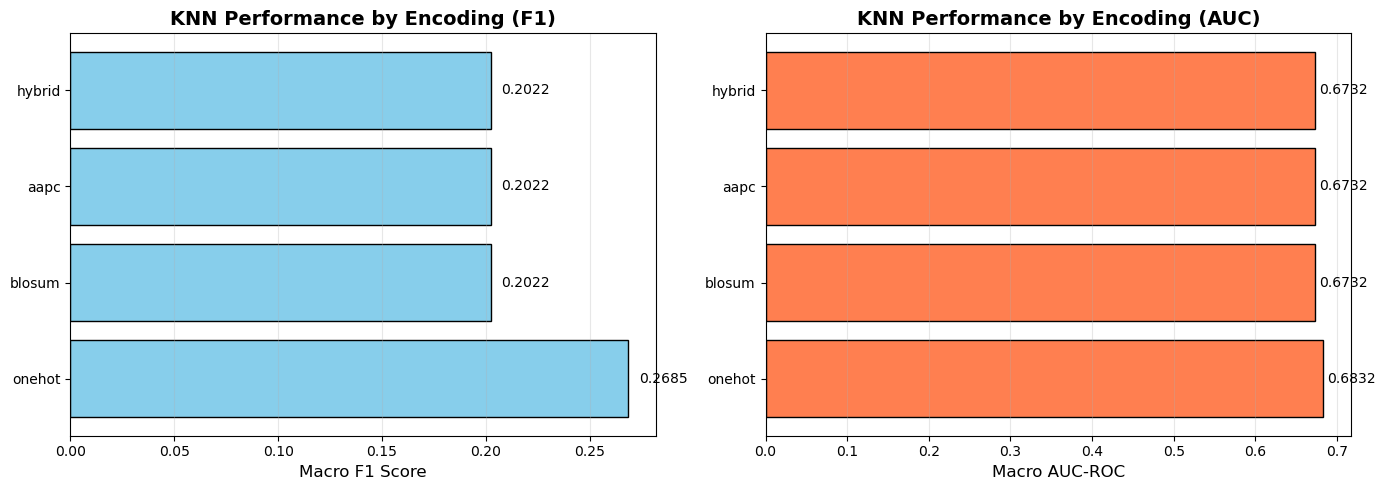

✓ Encoding comparison plot saved to: ../output/knn/visualizations/knn_encoding_comparison.png


In [6]:
# Create visualizations directory
viz_dir = os.path.join(OUTPUT_BASE_DIR, 'visualizations')
os.makedirs(viz_dir, exist_ok=True)

# Plot 1: Encoding Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1 scores
axes[0].barh(comparison_df['encoding'], comparison_df['macro_f1'], color='skyblue', edgecolor='black')
axes[0].set_xlabel('Macro F1 Score', fontsize=12)
axes[0].set_title('KNN Performance by Encoding (F1)', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for i, (enc, f1) in enumerate(zip(comparison_df['encoding'], comparison_df['macro_f1'])):
    axes[0].text(f1 + 0.005, i, f'{f1:.4f}', va='center', fontsize=10)

# AUC scores
axes[1].barh(comparison_df['encoding'], comparison_df['macro_auc'], color='coral', edgecolor='black')
axes[1].set_xlabel('Macro AUC-ROC', fontsize=12)
axes[1].set_title('KNN Performance by Encoding (AUC)', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for i, (enc, auc) in enumerate(zip(comparison_df['encoding'], comparison_df['macro_auc'])):
    axes[1].text(auc + 0.005, i, f'{auc:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(viz_dir, 'knn_encoding_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Encoding comparison plot saved to: {os.path.join(viz_dir, 'knn_encoding_comparison.png')}")


Generating per-label performance plot for best encoding (onehot)...


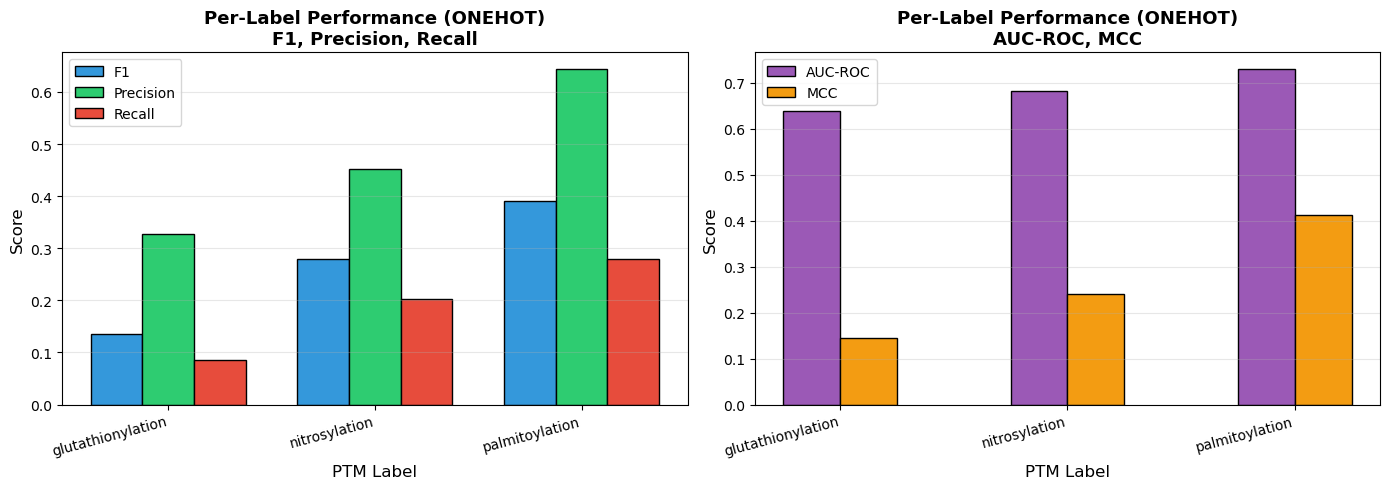

✓ Per-label performance plot saved to: ../output/knn/visualizations/knn_per_label_performance_onehot.png


In [7]:
# Plot 2: Per-Label Performance (Best Encoding)
print(f"\nGenerating per-label performance plot for best encoding ({best_encoding})...")

best_results_path = os.path.join(OUTPUT_BASE_DIR, best_encoding, 'knn_results.csv')
best_results_df = pd.read_csv(best_results_path)
best_results_df = best_results_df[best_results_df['label'] != 'MACRO_AVERAGE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1, Precision, Recall
x = np.arange(len(best_results_df))
width = 0.25

axes[0].bar(x - width, best_results_df['f1_score'], width, label='F1', color='#3498db', edgecolor='black')
axes[0].bar(x, best_results_df['precision'], width, label='Precision', color='#2ecc71', edgecolor='black')
axes[0].bar(x + width, best_results_df['recall'], width, label='Recall', color='#e74c3c', edgecolor='black')
axes[0].set_xlabel('PTM Label', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title(f'Per-Label Performance ({best_encoding.upper()})\nF1, Precision, Recall', 
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels([l.replace('S-', '') for l in best_results_df['label']], rotation=15, ha='right')
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# AUC and MCC
axes[1].bar(x - width/2, best_results_df['auc_roc'], width, label='AUC-ROC', color='#9b59b6', edgecolor='black')
axes[1].bar(x + width/2, best_results_df['mcc'], width, label='MCC', color='#f39c12', edgecolor='black')
axes[1].set_xlabel('PTM Label', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title(f'Per-Label Performance ({best_encoding.upper()})\nAUC-ROC, MCC', 
                  fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels([l.replace('S-', '') for l in best_results_df['label']], rotation=15, ha='right')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(viz_dir, f'knn_per_label_performance_{best_encoding}.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Per-label performance plot saved to: {os.path.join(viz_dir, f'knn_per_label_performance_{best_encoding}.png')}")

## 6. Summary

In [9]:
print("\n" + "="*70)
print("KNN TRAINING SUMMARY")
print("="*70)
print(f"\nAlgorithm: K-Nearest Neighbors")
print(f"Hyperparameters:")
print(f"  - n_neighbors: {N_NEIGHBORS}")
print(f"  - weights: {WEIGHTS}")
print(f"  - metric: {METRIC}")
print(f"\nEncodings Trained: {len(ENCODINGS)}")
for enc in ENCODINGS:
    print(f"  - {enc}")
print(f"\nBest Encoding: {best_encoding.upper()}")
print(f"  Macro F1:  {best_f1:.4f}")
print(f"  Macro AUC: {best_auc:.4f}")
print(f"\nOutput Structure:")
print(f"  {OUTPUT_BASE_DIR}/")
for enc in ENCODINGS:
    print(f"    ├── {enc}/")
    print(f"    │   ├── knn_models.pkl")
    print(f"    │   ├── knn_val_predictions.csv")
    print(f"    │   └── knn_results.csv")
print(f"    ├── knn_encoding_comparison.csv")
print(f"    └── visualizations/")
print(f"        ├── knn_encoding_comparison.png")
print(f"        └── knn_per_label_performance_{best_encoding}.png")
print("\n" + "="*70)
print("✓ KNN TRAINING COMPLETE!")
print("="*70)
print("\nNext Steps:")
print("1. Use predictions for ensemble (08_multi_encoding_ensemble.ipynb)")
print("2. Compare with RF, XGBoost, and SVM performance")
print("3. Consider hyperparameter tuning if needed (n_neighbors, metric)")
print("="*70)


KNN TRAINING SUMMARY

Algorithm: K-Nearest Neighbors
Hyperparameters:
  - n_neighbors: 5
  - weights: distance
  - metric: euclidean

Encodings Trained: 4
  - onehot
  - blosum
  - aapc
  - hybrid

Best Encoding: ONEHOT
  Macro F1:  0.2685
  Macro AUC: 0.6832

Output Structure:
  ../output/knn/
    ├── onehot/
    │   ├── knn_models.pkl
    │   ├── knn_val_predictions.csv
    │   └── knn_results.csv
    ├── blosum/
    │   ├── knn_models.pkl
    │   ├── knn_val_predictions.csv
    │   └── knn_results.csv
    ├── aapc/
    │   ├── knn_models.pkl
    │   ├── knn_val_predictions.csv
    │   └── knn_results.csv
    ├── hybrid/
    │   ├── knn_models.pkl
    │   ├── knn_val_predictions.csv
    │   └── knn_results.csv
    ├── knn_encoding_comparison.csv
    └── visualizations/
        ├── knn_encoding_comparison.png
        └── knn_per_label_performance_onehot.png

✓ KNN TRAINING COMPLETE!

Next Steps:
1. Use predictions for ensemble (08_multi_encoding_ensemble.ipynb)
2. Compare with RF, XG